In [ ]:
# Transformer
## 260910

sentences = ["The", "cat", "sat", "on", "the", "mat"]

attention_scores = {
    "The": 0.1,
    "cat": 1.0,
    "sat": 0.8,
    "on": 0.3,
    "the": 0.1,
    "mat": 0.6
}

In [4]:
word_vectors = {
    "The": [0.1, 0.2, 0.3],
    "cat": [0.5, 0.8, 0.2],
    "sat": [0.7, 0.1, 0.9],
    "on": [0.2, 0.6, 0.4],
    "the": [0.1, 0.2, 0.3],
    "mat": [0.8, 0.3, 0.5]
}

new_vector = []

for dim in range(3):
    weighted_sum = (
        0.1 * word_vectors['The'][dim] +
        1.0 * word_vectors['cat'][dim] +
        0.8 * word_vectors['sat'][dim] +
        0.3 * word_vectors['on'][dim] +
        0.1 * word_vectors['the'][dim] +
        0.6 * word_vectors['mat'][dim]
    )

    new_vector.append(weighted_sum)

print(word_vectors['cat'])
print(new_vector)


[0.5, 0.8, 0.2]
[1.6199999999999999, 1.28, 1.4000000000000001]


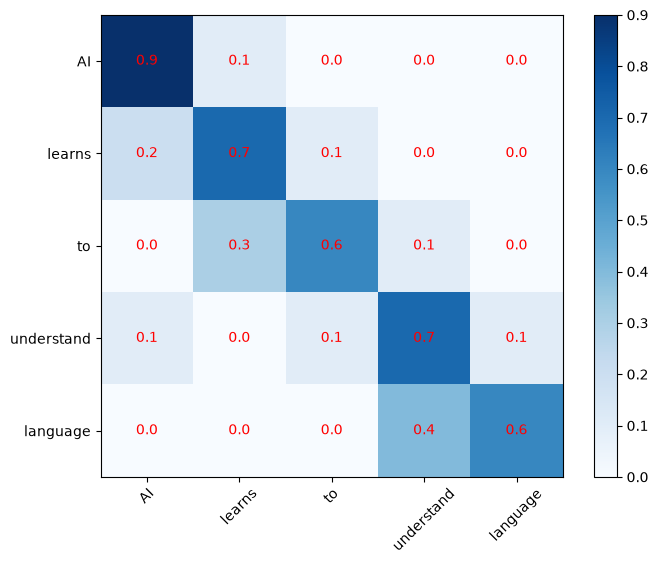

In [5]:
# Attention Heatmap

import matplotlib.pyplot as plt
import numpy as np

words = ["AI", "learns", "to", "understand", "language"]

attention_matrix = np.array([
    [0.9, 0.1, 0.0, 0.0, 0.0],
    [0.2, 0.7, 0.1, 0.0, 0.0],
    [0.0, 0.3, 0.6, 0.1, 0.0],
    [0.1, 0.0, 0.1, 0.7, 0.1],
    [0.0, 0.0, 0.0, 0.4, 0.6],
])

plt.figure(figsize = (8, 6))
plt.imshow(attention_matrix, cmap = "Blues")
plt.xticks(range(len(words)), words, rotation = 45)
plt.yticks(range(len(words)), words)
plt.colorbar()

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f"{attention_matrix[i, j]:.1f}",
                 ha = "center", va = "center", color = "red")

plt.show()

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SelfAttentionExplainer:
    def __init__(self, d_model = 512):
        self.d_model = d_model

    def step_by_step_attention(self, sentence):
        words = sentence.split()
        vocab_size = len(words)
        embeddings = torch.randn(vocab_size, self.d_model)

        for i, word in enumerate(words):
            print(word, embeddings[i][:5].tolist())

        W_q = torch.randn(self.d_model, self.d_model)
        W_k = torch.randn(self.d_model, self.d_model)
        W_v = torch.randn(self.d_model, self.d_model)

        Q = embeddings @W_q
        K = embeddings @W_k
        V = embeddings @W_v

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        scores = Q @ K.T / np.sqrt(self.d_model)
        print(scores)

        attention_weights = F.softmax(scores, dim = 1)

        plt.figure(figsize = (10, 8))
        plt.imshow(attention_weights.detach().numpy(), cmap = "Blues")
        plt.xticks(range(len(words)), words, rotation = 45)
        plt.yticks(range(len(words)), words)
        plt.colorbar()

        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(j, i, f"{attention_weights[i, j]:.2f}", ha = "center", va = "center", color = "red" if attention_weights[i, j] > 0.3 else "black")

        plt.tight_layout()
        plt.show()

        output = attention_weights @ V
        print(output.shape)

        for i, word in enumerate(words):
            top_attention = torch.argmax(attention_weights[i])
            top_word = words[top_attention]
            top_score = attention_weights[i, top_attention].item()

        return output, attention_weights

In [18]:
def run_attention_demo():
    explainer = SelfAttentionExplainer()
    sentences = [
        "The cat sat on the mat",
        "AI learns to understand language",
        "Transformer models revolutionized NLP"
    ]

    for sentence in sentences:
        output, weights = explainer.step_by_step_attention(sentence)

In [19]:
class PracticalAttentionExample:
    def __init__(self):
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim = 512,
            num_heads = 8,
            batch_first = True
        )

    def text_classification_with_attention(self):
        batch_size, seq_len, embed_dim = 2, 10, 512
        text_embeddings = torch.randn(batch_size, seq_len, embed_dim)
        attn_output, attn_weights = self.multihead_attn(
            text_embeddings, text_embeddings, text_embeddings
        )
        print(text_embeddings.shape)
        print(attn_output.shape)
        print(attn_weights.shape)

        classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.Dropout(0.1),
            nn.Linear(256, 3)
        )
        pooled = attn_output.mean(dim = 1)
        predictions = classifier(pooled)
        print(predictions.shape)

        return predictions

The [-0.7363081574440002, 1.3786722421646118, -0.7065432071685791, 0.1607997566461563, -0.9329772591590881]
cat [0.5560621619224548, -0.33787238597869873, 0.11551586538553238, 0.40383538603782654, 1.0280014276504517]
sat [0.09668724983930588, -0.8469792604446411, -0.9467950463294983, 0.06812109798192978, -0.19921404123306274]
on [-0.8433791995048523, -0.5846051573753357, -0.5749462842941284, 0.6227765679359436, 1.2052364349365234]
the [2.217256546020508, -1.4497804641723633, -0.5494754910469055, -1.8459835052490234, 2.317166328430176]
mat [0.8604710102081299, 0.6734734177589417, -1.1832386255264282, -0.5618759393692017, -1.1070469617843628]
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 512])
tensor([[ 327.4095, -739.0053,  705.1678,  398.6040, -364.4374,  612.0564],
        [ 477.4570, -687.8130,  746.9275,  -27.0350,  889.0366, -215.2868],
        [ 500.1329, -341.8513, -491.4738, -446.7732,  542.7521,  272.1113],
        [ 859.9902, -109.0049, -501.5146,  420.3161,  219.65

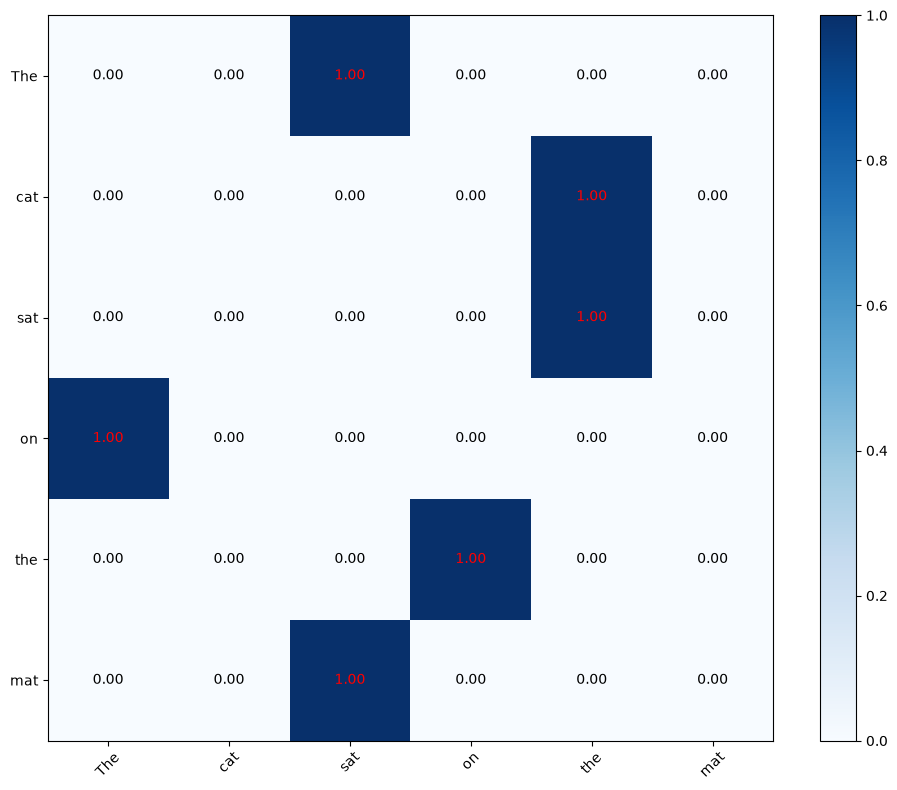

torch.Size([6, 512])
AI [0.4052039086818695, 0.02748860791325569, 1.627140760421753, -0.6899628639221191, 0.5615342259407043]
learns [-1.1333298683166504, 0.40083783864974976, -0.25133204460144043, -1.021180510520935, -1.3918615579605103]
to [-1.5094627141952515, 1.2734277248382568, 0.25810563564300537, -0.6103538274765015, 0.5388983488082886]
understand [1.4989814758300781, -0.6573336720466614, -0.6750991940498352, 1.0002946853637695, -1.1842782497406006]
language [1.1405829191207886, -0.15360568463802338, 1.1676005125045776, 2.676837205886841, 0.34214094281196594]
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 512])
tensor([[  -91.8530,  -169.3079,  -625.8088,  1393.8992,   639.1387],
        [  505.9352,  -458.3016,   278.8813,   767.4766,   -16.8466],
        [  222.3900,   212.0408,  -748.2999,  -146.9000,   406.3860],
        [ -351.2896,  -478.1240,   140.7522,   -49.6289,  -337.1247],
        [ -646.6951,  -376.8218, -1141.1169,  -317.0865,  -166.9758]])


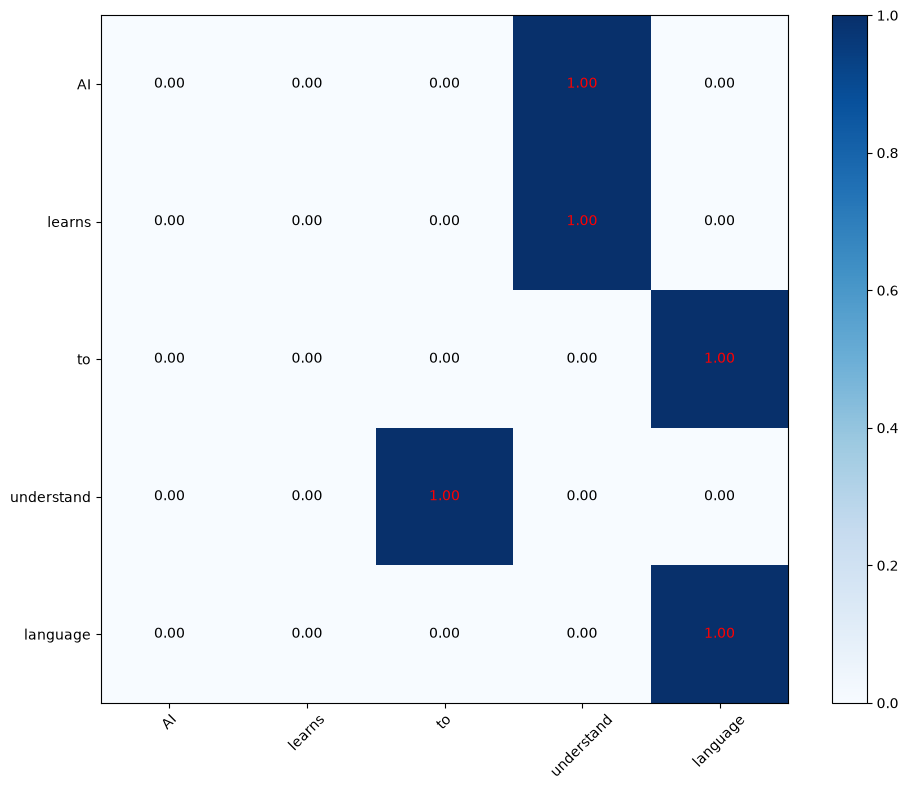

torch.Size([5, 512])
Transformer [-0.20198051631450653, -0.008378756232559681, -2.4369256496429443, 1.0492463111877441, 1.4145591259002686]
models [0.24049775302410126, -1.006329894065857, 0.183125302195549, -0.5213767290115356, 0.2064526081085205]
revolutionized [-1.594874382019043, 0.24189415574073792, -0.592605471611023, -0.4615405201911926, -0.5604078769683838]
NLP [1.845206618309021, -0.09029447287321091, 1.2763787508010864, -0.25651127099990845, 0.008430356159806252]
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 512])
tensor([[ 553.8551,  289.0444,  392.7949, -353.0479],
        [ -92.3377,  195.5600, -291.3676,  104.5939],
        [ 310.7813, -846.5453,  435.4912, -108.2793],
        [ 582.0869, -993.9656,  -85.7715,  210.9262]])


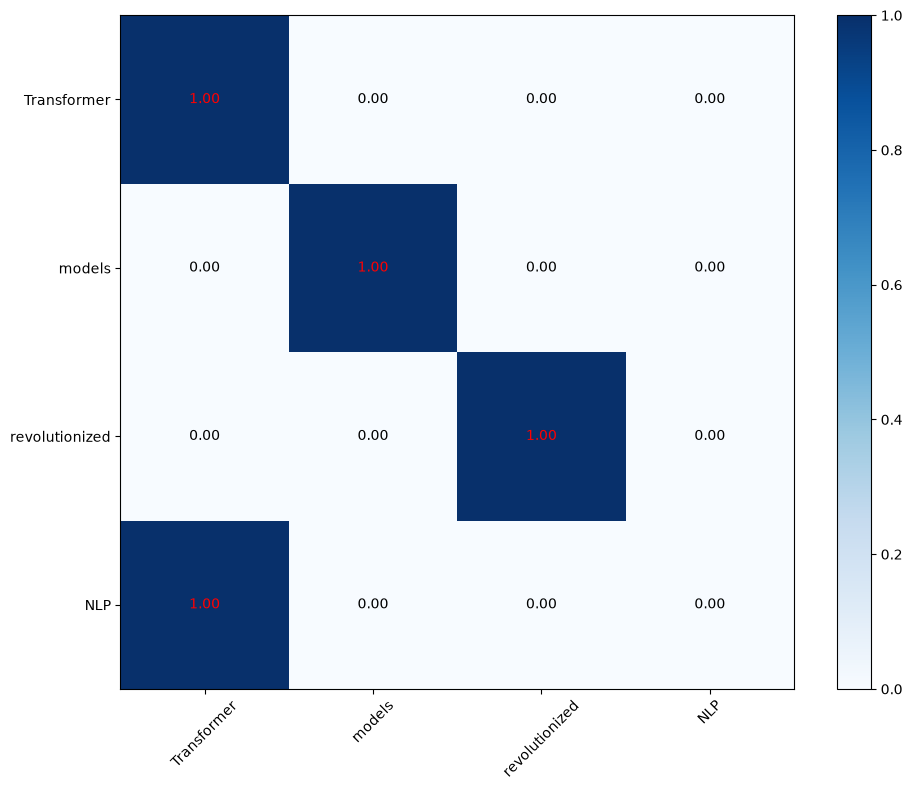

torch.Size([4, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 10])
torch.Size([2, 3])


tensor([[ 0.0681,  0.0003, -0.0331],
        [ 0.0675,  0.0024, -0.0752]], grad_fn=<AddmmBackward0>)

In [20]:
run_attention_demo()

practical = PracticalAttentionExample()
practical.text_classification_with_attention()

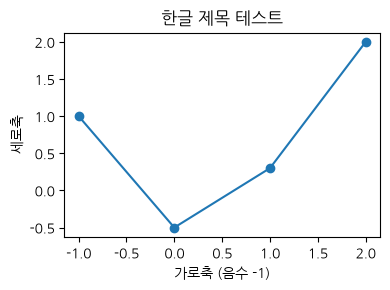

In [21]:
# 한글 폰트 설정 (나눔고딕)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_NAME = "NanumGothic"

# 설치된 폰트 목록에 나눔고딕이 있는지 확인
if FONT_NAME not in {f.name for f in fm.fontManager.ttflist}:
    # 혹시 폰트 캐시에 없으면 재스캔 시도
    fm._load_fontmanager(try_read_cache=False)

plt.rcParams["font.family"] = FONT_NAME
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# 확인용 플롯
plt.figure(figsize=(4, 3))
plt.plot([-1, 0, 1, 2], [1, -0.5, 0.3, 2], marker="o")
plt.title("한글 제목 테스트")
plt.xlabel("가로축 (음수 -1)")
plt.ylabel("세로축")
plt.tight_layout()
plt.show()

In [26]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# 전이학습
## 사전 학습된 ertTokenizer, BertForSequenceClassification 가져와서 감성분석

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)

# sentence = "This movie was fantastic!"
sentence = "I hate this movie"
inputs = tokenizer(sentence, return_tensors = "pt", truncation = True, padding = True)
outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim = 1)
print(predicted_class.item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0


In [28]:
from torch.utils.data import DataLoader, TensorDataset

sentences = ["I love this movie", "I hate this movie", "It was okay", "Fantastic Film", "Terrible experience"]
labels = torch.tensor([1, 0, 1, 1, 0])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_inputs = tokenizer(sentences, padding = True, truncation = True, return_tensors = "pt")

dataset = TensorDataset(encoded_inputs['input_ids'], labels)
train_loader = DataLoader(dataset, batch_size = 2, shuffle = True)

model_fe = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)

for param in model_fe.bert.parameters():
    param.requires_grad = False

optimizer_fe = optim.Adam(model_fe.parameters(), lr = 2e-5)
model_ft = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels = 2)
optimizer_ft = optim.Adam(model_ft.parameters(), lr = 2e-5)

def train_model(model, optimizer, epochs = 3):
    model.train()

    for epoch in range(epochs):
        for input_ids, label in train_loader:
            optimizer.zero_grad()
            outputs = model(input_ids = input_ids, labels = label)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

train_model(model_fe, optimizer_fe)
train_model(model_ft, optimizer_ft)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [32]:
outputs = model_fe(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim = 1)
print(predicted_class.item())

0


In [30]:
import torch
import torch.nn as nn
import torchvision.models as models

from torchvision import transforms
from PIL import Image

resnet18 = models.resnet18(pretrained = True)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

img = Image.open("./images/like_lenna.png").convert("RGB")
img_t = transform(img)
img_t = img_t.unsqueeze(0)
outputs = resnet18(img_t)
_, predicted = torch.max(outputs, 1)
print(predicted.item())

5


c:\Users\KDS-11\Documents\DeepLearning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\KDS-11\Documents\DeepLearning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
